In [ ]:
!pip install pandas seaborn matplotlib pyarrow

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.DataFrame({
    'Price': [500000,600000,700000,800000,900000,1000000,50000000],
    'Area': [1200,1500,1600,1800,2000,2200,3000],
    'Built_Year': [2010,2012,2015,2018,2020,2022,2000]
})

df

,Price,Area,Built_Year
0,500000,1200,2010
1,600000,1500,2012
2,700000,1600,2015
3,800000,1800,2018
4,900000,2000,2020
5,1000000,2200,2022
6,50000000,3000,2000


In [ ]:
df.to_csv("housing.csv", index=False)

for chunk in pd.read_csv("housing.csv", chunksize=3):
    print(chunk)

    Price  Area  Built_Year
0  500000  1200        2010
1  600000  1500        2012
2  700000  1600        2015
     Price  Area  Built_Year
3   800000  1800        2018
4   900000  2000        2020
5  1000000  2200        2022
      Price  Area  Built_Year
6  50000000  3000        2000


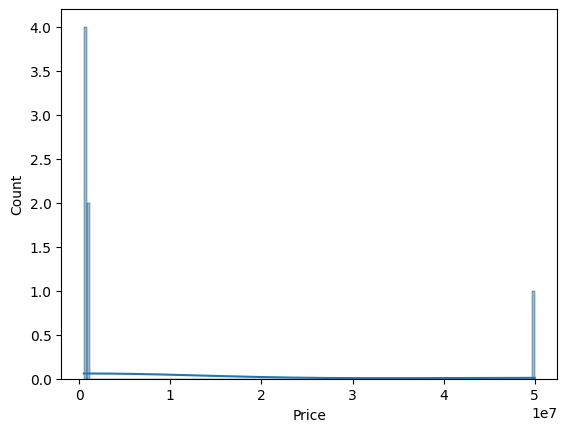

In [ ]:
sns.histplot(df['Price'], kde=True)
plt.show()

In [ ]:
mean = df['Price'].mean()
std = df['Price'].std()

df_clean = df[
    (df['Price'] >= mean - 3*std) &
    (df['Price'] <= mean + 3*std)
]

df_clean

,Price,Area,Built_Year
0,500000,1200,2010
1,600000,1500,2012
2,700000,1600,2015
3,800000,1800,2018
4,900000,2000,2020
5,1000000,2200,2022
6,50000000,3000,2000


In [ ]:
df_clean['Age_of_Home'] = 2025 - df_clean['Built_Year']
df_clean['Price_per_Sqft'] = df_clean['Price'] / df_clean['Area']
df_clean['Distance_to_City_Center'] = [5,7,10,12,15,18,20]

df_clean


,Price,Area,Built_Year,Age_of_Home,Price_per_Sqft,Distance_to_City_Center
0,500000,1200,2010,15,416.666667,5
1,600000,1500,2012,13,400.000000,7
2,700000,1600,2015,10,437.500000,10
3,800000,1800,2018,7,444.444444,12
4,900000,2000,2020,5,450.000000,15
5,1000000,2200,2022,3,454.545455,18
6,50000000,3000,2000,25,16666.666667,20


In [ ]:
df_clean.to_parquet("cleaned_housing.parquet")

print("Parquet file saved")

Parquet file saved


In [ ]:
from google.colab import files
files.download("cleaned_housing.parquet")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>